# Datenbasierte Marktpotenzialanalyse & -Prognose des regionalen Wohnmobilmarktes (2026)

# 1. Einleitung

## 1.1 Motivation und Projektziel

Dieses Projekt entstand im Rahmen eines freiberuflichen Beratungsauftrags zur Bewertung regionaler Marktpotenziale. Ziel war die Analyse des aktuellen Stands und die Ableitung des zukünftigen Marktpotenzials für Wohnmobile in einem spezifischen Zielmarkt in Bayern auf Basis öffentlich verfügbarer Daten.  

Dieser anonymisierte Projektauszug validiert die angewandte datenbasierte Methodik und demonstriert einen vollständigen Market-Intelligence-Workflow an der Schnittstelle von Marktverständnis, Datenanalyse, statistischer Regression und Plausibilisierung der abgeleitenen Erkenntnisse. 

## 1.2 Stakeholder

Aufgrund einer NDA mit dem Kunden bleiben die umfassenden strategischen Ableitungen und Business-Case-Details streng vertraulich.

# 2. Datenvorbereitung und -bereinigung

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression

## 2.1 Datenquellen

**KBA-Zulassungsdaten**  
https://www.kba.de/DE/Statistik/Produktkatalog/produkte/Fahrzeuge/fz1_b_uebersicht.html  

**BIP/Kopf**  
https://www.statistikportal.de/de/vgrdl/ergebnisse-kreisebene/bruttoinlandsprodukt-bruttowertschoepfung-kreise

## 2.2 Daten importieren, zusammen führen, Datenqualität überprüfen

Importieren der KBA-Zulassungsdaten, diese liegen teilweise im .xls und im .xlsx-Dateiformat vor:

In [2]:
# BITTE HIER DEN DATEIPFAD ZU DEN KBA-ZULASSUNGSDATEN EINFÜGEN
# kba_ordner = Path(r"PATH")

dateien = list(kba_ordner.glob("*.xlsx")) + list(kba_ordner.glob("*.xls"))
dateien = [f for f in dateien if "fz1_2025_bearbeitet_womodichte" not in f.name.lower()]

print(f"Gefundene KBA-Dateien: {len(dateien)}")
for f in dateien:
    print(f.name)

kba_liste = []

for datei in dateien:
    try:
        xls = pd.ExcelFile(datei)

        if "Kfz_u_Kfz_Anh" in xls.sheet_names:
            blattname = "Kfz_u_Kfz_Anh"
        elif "FZ1.1" in xls.sheet_names:
            blattname = "FZ1.1"
        else:
            print(f"Übersprungen: {datei.name} - kein passendes Blatt gefunden")
            continue

        df = pd.read_excel(datei, sheet_name=blattname, header=8)

        # Vorabfilterung: Nur die Spalten B, C, D (Land, Regierungsbezirk, Zulassungsbezirk) + J bis U (PKW) behalten
        spalten_indices = [1, 2, 3] + list(range(9, 21))  # B=1, C=2, D=3, J=9, U=20
        df = df.iloc[:, spalten_indices]

        match = re.search(r"(19|20)\d{2}", datei.stem)
        jahr = int(match.group(0)) if match else None

        df.insert(0, "quelle_datei", datei.name)
        df.insert(1, "jahr", jahr)
        df.insert(2, "blattname", blattname)

        kba_liste.append(df)

        print(f"Geladen: {datei.name} | Jahr: {jahr} | Blatt: {blattname} | Form: {df.shape}")

    except Exception as e:
        print(f"Fehler bei {datei.name}: {e}")

kba_raw = pd.concat(kba_liste, ignore_index=True)

print("\nKBA PKW-Daten geladen:")
print(kba_raw.head())
print("\nSpalten:")
print(kba_raw.columns.tolist())
print(f"\nShape: {kba_raw.shape}")

Gefundene KBA-Dateien: 8
fz1_2019_xlsx.xlsx
fz1_2020_xlsx.xlsx
fz1_2021.xlsx
fz1_2022.xlsx
fz1_2023.xlsx
fz1_2024.xlsx
fz1_2025.xlsx
fz1_2018_xls.xls
Geladen: fz1_2019_xlsx.xlsx | Jahr: 2019 | Blatt: Kfz_u_Kfz_Anh | Form: (450, 18)
Geladen: fz1_2020_xlsx.xlsx | Jahr: 2020 | Blatt: FZ1.1 | Form: (450, 18)
Geladen: fz1_2021.xlsx | Jahr: 2021 | Blatt: FZ1.1 | Form: (450, 18)
Geladen: fz1_2022.xlsx | Jahr: 2022 | Blatt: FZ1.1 | Form: (451, 18)
Geladen: fz1_2023.xlsx | Jahr: 2023 | Blatt: FZ1.1 | Form: (449, 18)
Geladen: fz1_2024.xlsx | Jahr: 2024 | Blatt: FZ1.1 | Form: (449, 18)
Geladen: fz1_2025.xlsx | Jahr: 2025 | Blatt: FZ1.1 | Form: (449, 18)
Geladen: fz1_2018_xls.xls | Jahr: 2018 | Blatt: Kfz_u_Kfz_Anh | Form: (450, 18)

KBA PKW-Daten geladen:
         quelle_datei  jahr      blattname                Land  \
0  fz1_2019_xlsx.xlsx  2019  Kfz_u_Kfz_Anh  BADEN-WUERTTEMBERG   
1  fz1_2019_xlsx.xlsx  2019  Kfz_u_Kfz_Anh                 NaN   
2  fz1_2019_xlsx.xlsx  2019  Kfz_u_Kfz_Anh     

In [3]:
# Anzeigen der 5 obersten Datensätze, um einen Überblick über die Daten zu bekommen
pd.set_option('display.max_columns', None)
kba_raw.head()

,quelle_datei,jahr,blattname,Land,Regierungsbezirk,Statistische Kennziffer und Zulassungsbezirk,insgesamt.1,Hubraum\nbis \n1.399 cm³,1.400\nbis\n1.999 cm³,2.000\nund\nmehr cm³,unbe-\nkannt,und zwar \nmit\noffenem\nAufbau,und zwar \nmit\nAllrad-\nantrieb,und zwar Wohn-\nmobile,"und zwar Kranken-\nwagen,\nNotarzt-\neinsatzfz.",und zwar gewerb-\nliche\nHalter,und zwar weib-\nliche\nHalter,PKW-Dichte\nje 1.000 \nEinwohner,"und zwar \nKranken-\nwagen,\nNotarzt-\neinsatzfz.",und zwar \ngewerbliche\nHalter,und zwar \nweibliche\nHalter,unbe-\nkannt,und zwar \ngewerbliche\nHalterinnen\nund Halter,und zwar\nHalterinnen
0,fz1_2019_xlsx.xlsx,2019,Kfz_u_Kfz_Anh,BADEN-WUERTTEMBERG,RB STUTTGART,"08111 STUTTGART,STADT",301793.0,89234.0,143302.0,67563.0,1694.0,19467.0,44724.0,2756.0,103,75586.0,83519.0,477,NaN,NaN,NaN,NaN,NaN,NaN
1,fz1_2019_xlsx.xlsx,2019,Kfz_u_Kfz_Anh,NaN,NaN,08115 BOEBLINGEN,253000.0,79766.0,119660.0,52240.0,1334.0,15297.0,33596.0,3011.0,71,38701.0,78155.0,649,NaN,NaN,NaN,NaN,NaN,NaN
2,fz1_2019_xlsx.xlsx,2019,Kfz_u_Kfz_Anh,NaN,NaN,08116 ESSLINGEN,329698.0,113823.0,158061.0,56845.0,969.0,19618.0,37471.0,3941.0,113,39359.0,110318.0,619,NaN,NaN,NaN,NaN,NaN,NaN
3,fz1_2019_xlsx.xlsx,2019,Kfz_u_Kfz_Anh,NaN,NaN,08117 GOEPPINGEN,163772.0,58862.0,77453.0,27124.0,333.0,8675.0,20210.0,2045.0,41,16181.0,55706.0,639,NaN,NaN,NaN,NaN,NaN,NaN
4,fz1_2019_xlsx.xlsx,2019,Kfz_u_Kfz_Anh,NaN,NaN,08118 LUDWIGSBURG,329497.0,112585.0,160124.0,55848.0,940.0,18933.0,36342.0,3390.0,143,28551.0,112880.0,607,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Reduktion der Spalten auf die für die Analyse benötigten
spalten_wunsch = [
    'jahr',
    'Statistische Kennziffer und Zulassungsbezirk',
    'insgesamt.1',
    'und zwar Wohn-\nmobile',
    'PKW-Dichte\nje 1.000 \nEinwohner'
]

kba_clean = kba_raw[spalten_wunsch].copy()

pd.set_option('display.max_columns', None)
print("KBA PKW-Daten (reduziert):")
print(kba_clean.head())
print(f"\nShape: {kba_clean.shape}")

KBA PKW-Daten (reduziert):
   jahr Statistische Kennziffer und Zulassungsbezirk  insgesamt.1  \
0  2019     08111  STUTTGART,STADT                       301793.0   
1  2019     08115  BOEBLINGEN                            253000.0   
2  2019     08116  ESSLINGEN                             329698.0   
3  2019     08117  GOEPPINGEN                            163772.0   
4  2019     08118  LUDWIGSBURG                           329497.0   

   und zwar Wohn-\nmobile PKW-Dichte\nje 1.000 \nEinwohner  
0                  2756.0                              477  
1                  3011.0                              649  
2                  3941.0                              619  
3                  2045.0                              639  
4                  3390.0                              607  

Shape: (3598, 5)


In [5]:
# Überblick über die reduzierten Spalten
kba_clean.head()

,jahr,Statistische Kennziffer und Zulassungsbezirk,insgesamt.1,und zwar Wohn-\nmobile,PKW-Dichte\nje 1.000 \nEinwohner
0,2019,"08111 STUTTGART,STADT",301793.0,2756.0,477
1,2019,08115 BOEBLINGEN,253000.0,3011.0,649
2,2019,08116 ESSLINGEN,329698.0,3941.0,619
3,2019,08117 GOEPPINGEN,163772.0,2045.0,639
4,2019,08118 LUDWIGSBURG,329497.0,3390.0,607


In [6]:
# 1. Spalten umbenennen (Mapping der kryptischen Excel-Namen auf saubere Namen)
# Nutzen der Strings mit \n, wie sie im DF vorliegen
mapping = {
    'insgesamt.1': 'Insgesamt',
    'und zwar Wohn-\nmobile': 'Wohnmobile',
    'PKW-Dichte\nje 1.000 \nEinwohner': 'PKW-Dichte je 1.000 Einwohner'
}

kba_clean = kba_clean.rename(columns=mapping)

# 2. Datentypen sicherstellen (numerische Werte erzwingen)
# Falls 'PKW-Dichte je 1.000 Einwohner' noch als Text vorliegt, konvertieren
cols_to_fix = ['Insgesamt', 'Wohnmobile', 'PKW-Dichte je 1.000 Einwohner']
for col in cols_to_fix:
    kba_clean[col] = pd.to_numeric(kba_clean[col], errors='coerce')

# 3. Neue Spalten berechnen: Einwohnerzahl, Wohnmobildichte
# Berechnung der Einwohnerzahl aus der PKW-Gesamtzahl und der Dichte
kba_clean['Einwohnerzahl'] = (kba_clean['Insgesamt'] / kba_clean['PKW-Dichte je 1.000 Einwohner']) * 1000

# Berechnung der Wohnmobildichte pro 1.000 Einwohner
kba_clean['Wohnmobildichte pro 1.000 Einwohner'] = kba_clean['Wohnmobile'] / (kba_clean['Einwohnerzahl'] / 1000)

# 4. Ergebnis prüfen
print("--- KBA_CLEAN MIT NEUEN BERECHNUNGEN ---")
print()
print(kba_clean[['jahr', 'Statistische Kennziffer und Zulassungsbezirk', 'Einwohnerzahl', 'Wohnmobildichte pro 1.000 Einwohner']].head())

--- KBA_CLEAN MIT NEUEN BERECHNUNGEN ---

   jahr Statistische Kennziffer und Zulassungsbezirk  Einwohnerzahl  \
0  2019     08111  STUTTGART,STADT                    632689.727463   
1  2019     08115  BOEBLINGEN                         389830.508475   
2  2019     08116  ESSLINGEN                          532630.048465   
3  2019     08117  GOEPPINGEN                         256294.209703   
4  2019     08118  LUDWIGSBURG                        542828.665568   

   Wohnmobildichte pro 1.000 Einwohner  
0                             4.356006  
1                             7.723870  
2                             7.399132  
3                             7.979111  
4                             6.245064  


In [7]:
kba_clean.head()

,jahr,Statistische Kennziffer und Zulassungsbezirk,Insgesamt,Wohnmobile,PKW-Dichte je 1.000 Einwohner,Einwohnerzahl,Wohnmobildichte pro 1.000 Einwohner
0,2019,"08111 STUTTGART,STADT",301793.0,2756.0,477.0,632689.727463,4.356006
1,2019,08115 BOEBLINGEN,253000.0,3011.0,649.0,389830.508475,7.723870
2,2019,08116 ESSLINGEN,329698.0,3941.0,619.0,532630.048465,7.399132
3,2019,08117 GOEPPINGEN,163772.0,2045.0,639.0,256294.209703,7.979111
4,2019,08118 LUDWIGSBURG,329497.0,3390.0,607.0,542828.665568,6.245064


Die Spalte "Statistische Kennziffer und Zulassungsbezirk" enthält die PLZ und den Namen des Regierungsbezirks, für die bessere Analyse werden diese voneinander getrennt und im Folgenden nur die PLZ verwendet:

In [8]:
# Die Spalte 'Statistische Kennziffer und Zulassungsbezirk' am ersten Leerzeichen splitten
# expand=True erstellt daraus neue Spalten
split_data = kba_clean['Statistische Kennziffer und Zulassungsbezirk'].str.split(' ', n=1, expand=True)

# Die neue Spalte 'PLZ' erstellen (nimmt den ersten Teil vor dem Leerzeichen)
kba_clean['PLZ'] = split_data[0]

# Optional: Den Namen des Bezirks (ohne die Nummer) in eine eigene Spalte schreiben
kba_clean['zulassungsbezirk_name'] = split_data[1].str.strip()

# Kontrolle
print(kba_clean[['PLZ', 'zulassungsbezirk_name', 'jahr']].head())

     PLZ zulassungsbezirk_name  jahr
0  08111       STUTTGART,STADT  2019
1  08115            BOEBLINGEN  2019
2  08116             ESSLINGEN  2019
3  08117            GOEPPINGEN  2019
4  08118           LUDWIGSBURG  2019


In [9]:
kba_clean.head()

,jahr,Statistische Kennziffer und Zulassungsbezirk,Insgesamt,Wohnmobile,PKW-Dichte je 1.000 Einwohner,Einwohnerzahl,Wohnmobildichte pro 1.000 Einwohner,PLZ,zulassungsbezirk_name
0,2019,"08111 STUTTGART,STADT",301793.0,2756.0,477.0,632689.727463,4.356006,08111,"STUTTGART,STADT"
1,2019,08115 BOEBLINGEN,253000.0,3011.0,649.0,389830.508475,7.723870,08115,BOEBLINGEN
2,2019,08116 ESSLINGEN,329698.0,3941.0,619.0,532630.048465,7.399132,08116,ESSLINGEN
3,2019,08117 GOEPPINGEN,163772.0,2045.0,639.0,256294.209703,7.979111,08117,GOEPPINGEN
4,2019,08118 LUDWIGSBURG,329497.0,3390.0,607.0,542828.665568,6.245064,08118,LUDWIGSBURG


**Zusammenfassung:**  
Damit ist der Datenimport und die Datenbereinigung abgeschlossen.

# 3. Datenanalyse

## 3.1 Analyse der Top-Regionen

Als nächstes sollen nur die Top 5 Regierungsbezirke betrachtet werden.  

Dafür werden zunächst die Top 5 PLZ für das Jahr 2025 sowie den Zeitraum 2018-2025 gefiltert:

In [10]:
# 1. Top 5 für das Jahr 2025 (direkt aus kba_clean)
top_5_2025 = (
    kba_clean[kba_clean['jahr'] == 2025]
    .sort_values('Wohnmobildichte pro 1.000 Einwohner', ascending=False)
    .head(5)
)

# 2. Top 5 im Durchschnitt über den gesamten Zeitraum 2018-2025
# Gruppieren über alle verfügbaren Jahre im kba_clean
top_5_schnitt_langzeit = (
    kba_clean.groupby(['Statistische Kennziffer und Zulassungsbezirk'])['Wohnmobildichte pro 1.000 Einwohner']
    .mean()
    .reset_index()
    .sort_values('Wohnmobildichte pro 1.000 Einwohner', ascending=False)
    .head(5)
)

# Ausgabe der Ergebnisse
print("--- TOP 5 REGIONEN: NUR JAHR 2025 ---")
print()
print(top_5_2025[['jahr', 'Statistische Kennziffer und Zulassungsbezirk', 'Wohnmobildichte pro 1.000 Einwohner']].to_string(index=False))

print("\n--- TOP 5 REGIONEN: DURCHSCHNITT (2018-2025) ---")
print()
print(top_5_schnitt_langzeit.to_string(index=False))

--- TOP 5 REGIONEN: NUR JAHR 2025 ---

 jahr Statistische Kennziffer und Zulassungsbezirk  Wohnmobildichte pro 1.000 Einwohner
 2025                        06414 WIESBADEN,STADT                            33.670292
 2025                    01059 SCHLESWIG-FLENSBURG                            28.720074
 2025                          01054 NORDFRIESLAND                            28.011133
 2025                 09180 GARMISCH-PARTENKIRCHEN                            26.912411
 2025                                  01057 PLOEN                            26.706072

--- TOP 5 REGIONEN: DURCHSCHNITT (2018-2025) ---

Statistische Kennziffer und Zulassungsbezirk  Wohnmobildichte pro 1.000 Einwohner
                   01059 SCHLESWIG-FLENSBURG                            26.870143
                         01054 NORDFRIESLAND                            25.772036
                09180 GARMISCH-PARTENKIRCHEN                            25.282739
                                 01057 PLOEN          

Der langjährige Durchschnitt ist fast identisch mit den Spitzenreitern 2025: im Jahr 2025 ist Wiesbaden mit in den Top 5, aber nicht im langjährigen Mittel. Im langjährigen imttel ist dasfür Weilheim-Schongau mit vertreten.

Um eine Liste mit den Regierungsbezirken zu generieren, die sowohl im langjährigen Mittel als auch 2025 in den Top 5 sind, wird die Schnittmenge der beiden Listen erstellt:

In [15]:
# 1. Die Top 5 PLZ und Namen der Regierungsbezirke für 2025 extrahieren
top_5_2025_set = set(top_5_2025['Statistische Kennziffer und Zulassungsbezirk'])

# 2. Die Top 5 PLZ und Namen der Regierungsbezirke aus 2018-2025 extrahieren
top_5_schnitt_set = set(top_5_schnitt_langzeit['Statistische Kennziffer und Zulassungsbezirk'])

# 3. Schnittmenge bilden
ueberschneidung = top_5_2025_set.intersection(top_5_schnitt_set)

# 4. Details zur Schnittmenge anzeigen (Werte von 2025)
ergebnis_df = top_5_2025[top_5_2025['Statistische Kennziffer und Zulassungsbezirk'].isin(ueberschneidung)]

print("--- SCHNITTMENGE: TOP 5 AKTUELL (2025) & TOP 5 LANGZEIT (2018-2025) ---")
if ueberschneidung:
    print(ergebnis_df[['Statistische Kennziffer und Zulassungsbezirk', 'Wohnmobildichte pro 1.000 Einwohner']].sort_values('Wohnmobildichte pro 1.000 Einwohner', ascending=False).to_string(index=False))
    print()
    print(f"\nAnzahl der stabilen Spitzenreiter: {len(ueberschneidung)}")
else:
    print("Keine Überschneidung gefunden – die Top 5 von 2025 sind komplett andere als im Langzeit-Schnitt.")

--- SCHNITTMENGE: TOP 5 AKTUELL (2025) & TOP 5 LANGZEIT (2018-2025) ---
Statistische Kennziffer und Zulassungsbezirk  Wohnmobildichte pro 1.000 Einwohner
                   01059 SCHLESWIG-FLENSBURG                            28.720074
                         01054 NORDFRIESLAND                            28.011133
                09180 GARMISCH-PARTENKIRCHEN                            26.912411
                                 01057 PLOEN                            26.706072


Anzahl der stabilen Spitzenreiter: 4


Für die Analyse wird jedoch der umfangreichere Datensatz verwendet: die Kombination beider Listen, welche damit die Top 6 ergeben:

In [16]:
# 1. Die Top 5 für das Jahr 2025 (Basis: kba_clean)
top_5_2025 = kba_clean[kba_clean['jahr'] == 2025].sort_values(
    'Wohnmobildichte pro 1.000 Einwohner', ascending=False
).head(5)

# 2. Die Top 5 für den Langzeit-Durchschnitt 2018-2025 (Basis: kba_clean)
# Gruppieren, um die stabilsten Regionen über den gesamten Zeitraum zu finden
top_5_historie = kba_clean.groupby('Statistische Kennziffer und Zulassungsbezirk')[
    'Wohnmobildichte pro 1.000 Einwohner'
].mean().reset_index().sort_values(
    'Wohnmobildichte pro 1.000 Einwohner', ascending=False
).head(5)

# 3. Vereinigung der beiden Listen
set_2025 = set(top_5_2025['Statistische Kennziffer und Zulassungsbezirk'])
set_historie = set(top_5_historie['Statistische Kennziffer und Zulassungsbezirk'])

vereinigte_namen_liste = list(set_2025.union(set_historie))

# 4. Erstellung des finalen DataFrames für die Anzeige
vereinigte_top_liste = kba_clean[
    (kba_clean['jahr'] == 2025) & 
    (kba_clean['Statistische Kennziffer und Zulassungsbezirk'].isin(vereinigte_namen_liste))
].sort_values('Wohnmobildichte pro 1.000 Einwohner', ascending=False)

# 5. Anzeige der Ergebnisse
print(f"--- VEREINIGTE TOP-LISTE (Anzahl: {len(vereinigte_top_liste)}) ---")
print()
print(vereinigte_top_liste[['Statistische Kennziffer und Zulassungsbezirk', 'Wohnmobildichte pro 1.000 Einwohner']].to_string(index=False))

# Optional: Markierung, wer "Neu" ist (Wiesbaden)
print("\n--- ANALYSE DER ZUSAMMENSETZUNG ---")
print()
spalten_breite = 30
for name in vereinigte_namen_liste:
    status = []
    if name in set_2025: status.append("Top 2025")
    if name in set_historie: status.append("Top Historie")
    print(f"{name:<{spalten_breite}}: {' & '.join(status)}")

--- VEREINIGTE TOP-LISTE (Anzahl: 6) ---

Statistische Kennziffer und Zulassungsbezirk  Wohnmobildichte pro 1.000 Einwohner
                       06414 WIESBADEN,STADT                            33.670292
                   01059 SCHLESWIG-FLENSBURG                            28.720074
                         01054 NORDFRIESLAND                            28.011133
                09180 GARMISCH-PARTENKIRCHEN                            26.912411
                                 01057 PLOEN                            26.706072
                     09190 WEILHEIM-SCHONGAU                            25.960644

--- ANALYSE DER ZUSAMMENSETZUNG ---

09180 GARMISCH-PARTENKIRCHEN  : Top 2025 & Top Historie
01057 PLOEN                   : Top 2025 & Top Historie
09190 WEILHEIM-SCHONGAU       : Top Historie
06414 WIESBADEN,STADT         : Top 2025
01059 SCHLESWIG-FLENSBURG     : Top 2025 & Top Historie
01054 NORDFRIESLAND           : Top 2025 & Top Historie


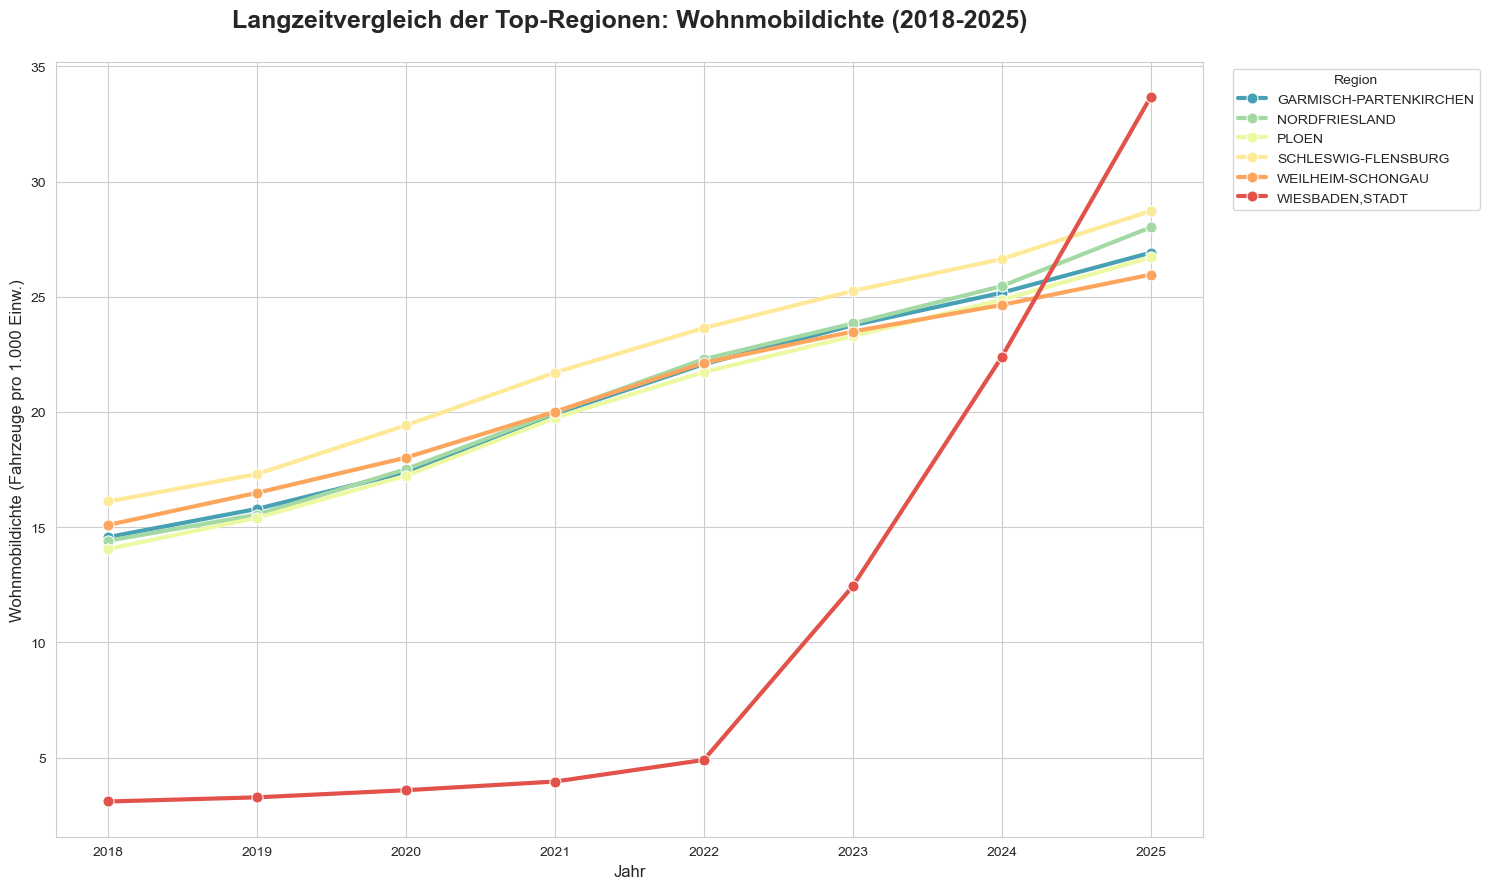

In [19]:
# 1. Die finale Liste der 6 PLZ
top_6_plz = [name[:5] for name in vereinigte_namen_liste]

# 2. Daten filtern aus kba_clean
# Verwendung von .isin() auf der Spalte 'PLZ', um NaN-Fehler zu vermeiden
df_plot_full = kba_clean[kba_clean['PLZ'].isin(top_6_plz)].copy()

# Sortieren für saubere Linienführung (wichtig für Zeitreihen)
df_plot_full = df_plot_full.sort_values(['zulassungsbezirk_name', 'jahr'])

# 3. Plot erstellen
plt.figure(figsize=(15, 9))
sns.set_style("whitegrid")

# Liniendiagramm
plot = sns.lineplot(
    data=df_plot_full, 
    x='jahr', 
    y='Wohnmobildichte pro 1.000 Einwohner', 
    hue='zulassungsbezirk_name', 
    marker='o', 
    markersize=8,
    linewidth=3,
    palette='Spectral_r'
)

# 4. Styling & Beschriftung
plt.title('Langzeitvergleich der Top-Regionen: Wohnmobildichte (2018-2025)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Wohnmobildichte (Fahrzeuge pro 1.000 Einw.)', fontsize=12)

# Legende außerhalb des Plots platzieren
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

# X-Achse auf ganze Jahre fixieren
plt.xticks(range(2018, 2026))

# 5. Grafik als JPEG exportieren
plt.savefig('womo_vergleich_2018_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

Erweiterung des Diagramms: Einfügen der PLZ der Regierungsbezirke aus dem Zielmarkt

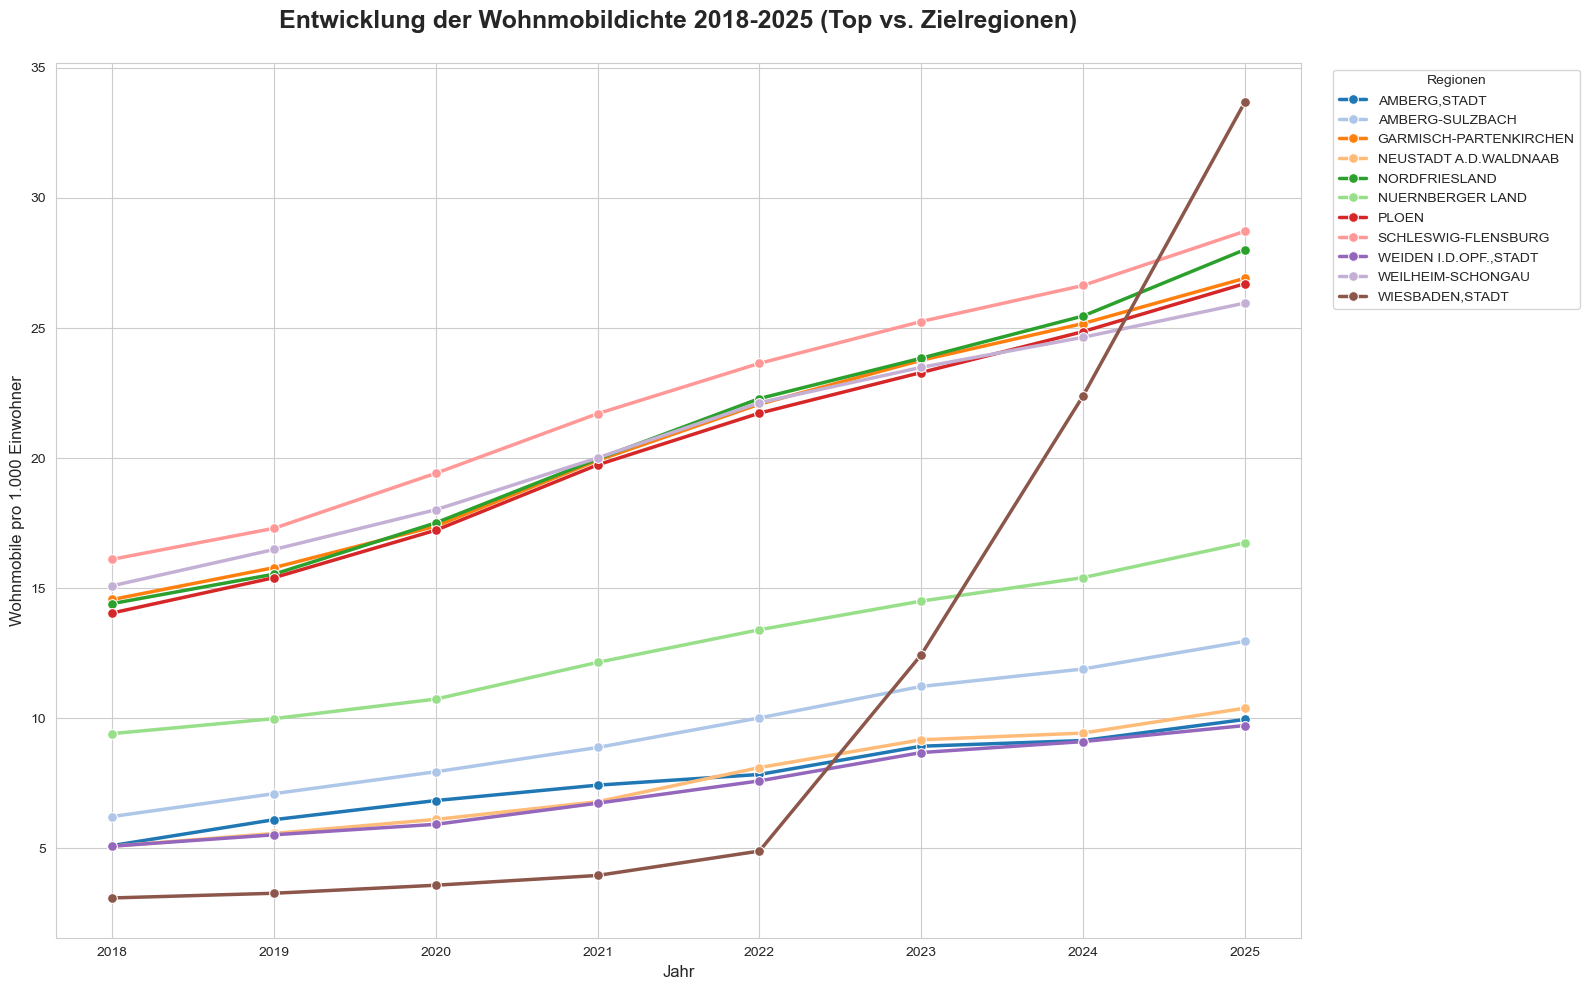

In [22]:
# 1. PLZ des Zielmarktes manuell definieren
ziel_plz = ['09361', '09363', '09371', '09374', '09574']           
alle_plz = top_6_plz + ziel_plz

# 2. Filtern aus kba_clean
df_zeitreihe = kba_clean[kba_clean['PLZ'].isin(alle_plz)].copy()

# Sortieren für saubere Linien
df_zeitreihe = df_zeitreihe.sort_values(['zulassungsbezirk_name', 'jahr'])

# 3. Plot erstellen
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

# Nutzung einer kontrastreichen Palette
palette = sns.color_palette("tab20", len(alle_plz))

# Plotten
plot = sns.lineplot(
    data=df_zeitreihe, 
    x='jahr', 
    y='Wohnmobildichte pro 1.000 Einwohner', 
    hue='zulassungsbezirk_name', 
    marker='o', 
    markersize=7,
    linewidth=2.5,
    palette=palette
)

# 4. Styling
plt.title('Entwicklung der Wohnmobildichte 2018-2025 (Top vs. Zielregionen)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Wohnmobile pro 1.000 Einwohner', fontsize=12)

# Legende optimieren
plt.legend(title='Regionen', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

# X-Achse auf ganze Jahre einstellen
plt.xticks(range(2018, 2026))

# 5. Export als JPEG
plt.savefig('zeitreihe_womo_2018_2025_alle.jpg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## 3.1 Plausibilisierung der Unterschiede in der Wohnmobildichte durch die Wirtschaftskraft der Regionen

Als möglicher Erklärungsfaktor für die Unterschiede in der Wohnmobildichte könnte die Wirtschaftskraft in Frage kommen. Um dies zu unteresuchen wird zunächst ein Excel-Datensatz mit Daten zum BIP/Kopf importiert:

In [27]:
# BITTE HIER DEN DATEIPFAD ZU DEN BIP/KOPF-DATEN EINFÜGEN
#file_path = r"PATH"

# Das Argument dtype={'Regional-schlüssel': str} erzwingt das Textformat beim Einlesen
bip_kopf_df = pd.read_excel(file_path, dtype={'Regional-schlüssel': str})

# Optional: Leerzeichen entfernen, falls vorhanden
bip_kopf_df['Regional-schlüssel'] = bip_kopf_df['Regional-schlüssel'].str.strip()

In [28]:
bip_kopf_df.head()

,Regional-schlüssel,Land,NUTS 1,NUTS 2,NUTS 3,Gebietseinheit,2018,2019,2020,2021,2022,2023
0,08,BW,1.0,NaN,NaN,Baden-Württemberg,47656,48362,46559,49997,53145,55840
1,081,BW,NaN,2.0,NaN,"Stuttgart, Regierungsbezirk",54527,54461,52506,57574,61697,65180
2,08111,BW,NaN,NaN,3.0,"Stuttgart, Landeshauptstadt, Stadtkreis",89190,88732,84502,97029,104580,112183
3,08115,BW,NaN,NaN,3.0,"Böblingen, Landkreis",69102,64219,61439,72609,79921,83120
4,08116,BW,NaN,NaN,3.0,"Esslingen, Landkreis",44477,44285,41154,46020,49698,51626


Die BIP/Kopf-Daten liegen nur bis 2023 vor, was die Analyse ggü. den Wohnmobildaten um 2 Jahre einschränkt.

In [29]:
# Neben den 5-stelligen PLZ-Bereichen liegen auch noch höher aggregierte Bereich vor (z.B. Bundesländern), diese werden nicht benötigt
bip_kopf_df = bip_kopf_df[bip_kopf_df['Regional-schlüssel'].str.len() == 5].copy()

# Kontrolle der ersten Zeilen
print(f"Anzahl der Landkreise/Stadtkreise: {len(bip_kopf_df)}")
print()
print(bip_kopf_df.head())

Anzahl der Landkreise/Stadtkreise: 398

  Regional-schlüssel Land  NUTS 1  NUTS 2  NUTS 3  \
2              08111   BW     NaN     NaN     3.0   
3              08115   BW     NaN     NaN     3.0   
4              08116   BW     NaN     NaN     3.0   
5              08117   BW     NaN     NaN     3.0   
6              08118   BW     NaN     NaN     3.0   

                            Gebietseinheit   2018   2019   2020   2021  \
2  Stuttgart, Landeshauptstadt, Stadtkreis  89190  88732  84502  97029   
3                     Böblingen, Landkreis  69102  64219  61439  72609   
4                     Esslingen, Landkreis  44477  44285  41154  46020   
5                     Göppingen, Landkreis  34360  34053  32142  34280   
6                   Ludwigsburg, Landkreis  47352  47923  48252  49033   

     2022    2023  
2  104580  112183  
3   79921   83120  
4   49698   51626  
5   35012   36672  
6   52797   56524  


In [30]:
bip_kopf_df.head()

,Regional-schlüssel,Land,NUTS 1,NUTS 2,NUTS 3,Gebietseinheit,2018,2019,2020,2021,2022,2023
2,08111,BW,NaN,NaN,3.0,"Stuttgart, Landeshauptstadt, Stadtkreis",89190,88732,84502,97029,104580,112183
3,08115,BW,NaN,NaN,3.0,"Böblingen, Landkreis",69102,64219,61439,72609,79921,83120
4,08116,BW,NaN,NaN,3.0,"Esslingen, Landkreis",44477,44285,41154,46020,49698,51626
5,08117,BW,NaN,NaN,3.0,"Göppingen, Landkreis",34360,34053,32142,34280,35012,36672
6,08118,BW,NaN,NaN,3.0,"Ludwigsburg, Landkreis",47352,47923,48252,49033,52797,56524


Zur Untersuchung der Wohnmobildaten zusammen mit den BIP/Kopf-Daten werden die beiden DF´s gemerged:

In [31]:
# 1. BIP-Daten vorbereiten (von Breit- in Langformat wandeln)
# Die Jahre aus den Spaltenüberschriften in eine eigene Spalte 'jahr' überführen
bip_years_cols = [col for col in bip_kopf_df.columns if str(col) in ['2018', '2019', '2020', '2021', '2022', '2023']]

bip_long = pd.melt(
    bip_kopf_df, 
    id_vars=['Regional-schlüssel', 'Gebietseinheit'], 
    value_vars=bip_years_cols, 
    var_name='jahr', 
    value_name='BIP_pro_Kopf'
)

# 2. Datentypen für den Match harmonisieren
# Jahre als Integer
bip_long['jahr'] = bip_long['jahr'].astype(int)
kba_clean['jahr'] = kba_clean['jahr'].astype(int)

# PLZ als saubere 5-stellige Strings (wichtig für die führende Null bei manchen PLZ)
bip_long['Regional-schlüssel'] = bip_long['Regional-schlüssel'].astype(str).str.strip().str.zfill(5)

# Falls die Spalte in kba_clean noch 'Statistische Kennziffer und Zulassungsbezirk' heißt: extrahieren der ersten 5 Zeichen als neue 'PLZ' Spalte:
kba_clean['PLZ'] = kba_clean['Statistische Kennziffer und Zulassungsbezirk'].astype(str).str[:5].str.strip().str.zfill(5)

# 3. Der finale Merge über zwei Spalten: PLZ und jahr
merged_df = pd.merge(
    kba_clean,
    bip_long,
    left_on=['PLZ', 'jahr'],
    right_on=['Regional-schlüssel', 'jahr'],
    how='inner'
)

# 4. Spalten-Cleanup (Doppelte Schlüsselspalte entfernen)
if 'Regional-schlüssel' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Regional-schlüssel'])

print("--- MERGE ERFOLGREICH ---")
print()
print(f"Anzahl Datensätze: {len(merged_df)}")
print()
print(merged_df[['jahr', 'PLZ', 'Wohnmobildichte pro 1.000 Einwohner', 'BIP_pro_Kopf']].head())

--- MERGE ERFOLGREICH ---

Anzahl Datensätze: 2382

   jahr    PLZ  Wohnmobildichte pro 1.000 Einwohner  BIP_pro_Kopf
0  2019  08111                             4.356006         88732
1  2019  08115                             7.723870         64219
2  2019  08116                             7.399132         44285
3  2019  08117                             7.979111         34053
4  2019  08118                             6.245064         47923


In [32]:
merged_df.head()

,jahr,Statistische Kennziffer und Zulassungsbezirk,Insgesamt,Wohnmobile,PKW-Dichte je 1.000 Einwohner,Einwohnerzahl,Wohnmobildichte pro 1.000 Einwohner,PLZ,zulassungsbezirk_name,Gebietseinheit,BIP_pro_Kopf
0,2019,"08111 STUTTGART,STADT",301793.0,2756.0,477.0,632689.727463,4.356006,08111,"STUTTGART,STADT","Stuttgart, Landeshauptstadt, Stadtkreis",88732
1,2019,08115 BOEBLINGEN,253000.0,3011.0,649.0,389830.508475,7.723870,08115,BOEBLINGEN,"Böblingen, Landkreis",64219
2,2019,08116 ESSLINGEN,329698.0,3941.0,619.0,532630.048465,7.399132,08116,ESSLINGEN,"Esslingen, Landkreis",44285
3,2019,08117 GOEPPINGEN,163772.0,2045.0,639.0,256294.209703,7.979111,08117,GOEPPINGEN,"Göppingen, Landkreis",34053
4,2019,08118 LUDWIGSBURG,329497.0,3390.0,607.0,542828.665568,6.245064,08118,LUDWIGSBURG,"Ludwigsburg, Landkreis",47923


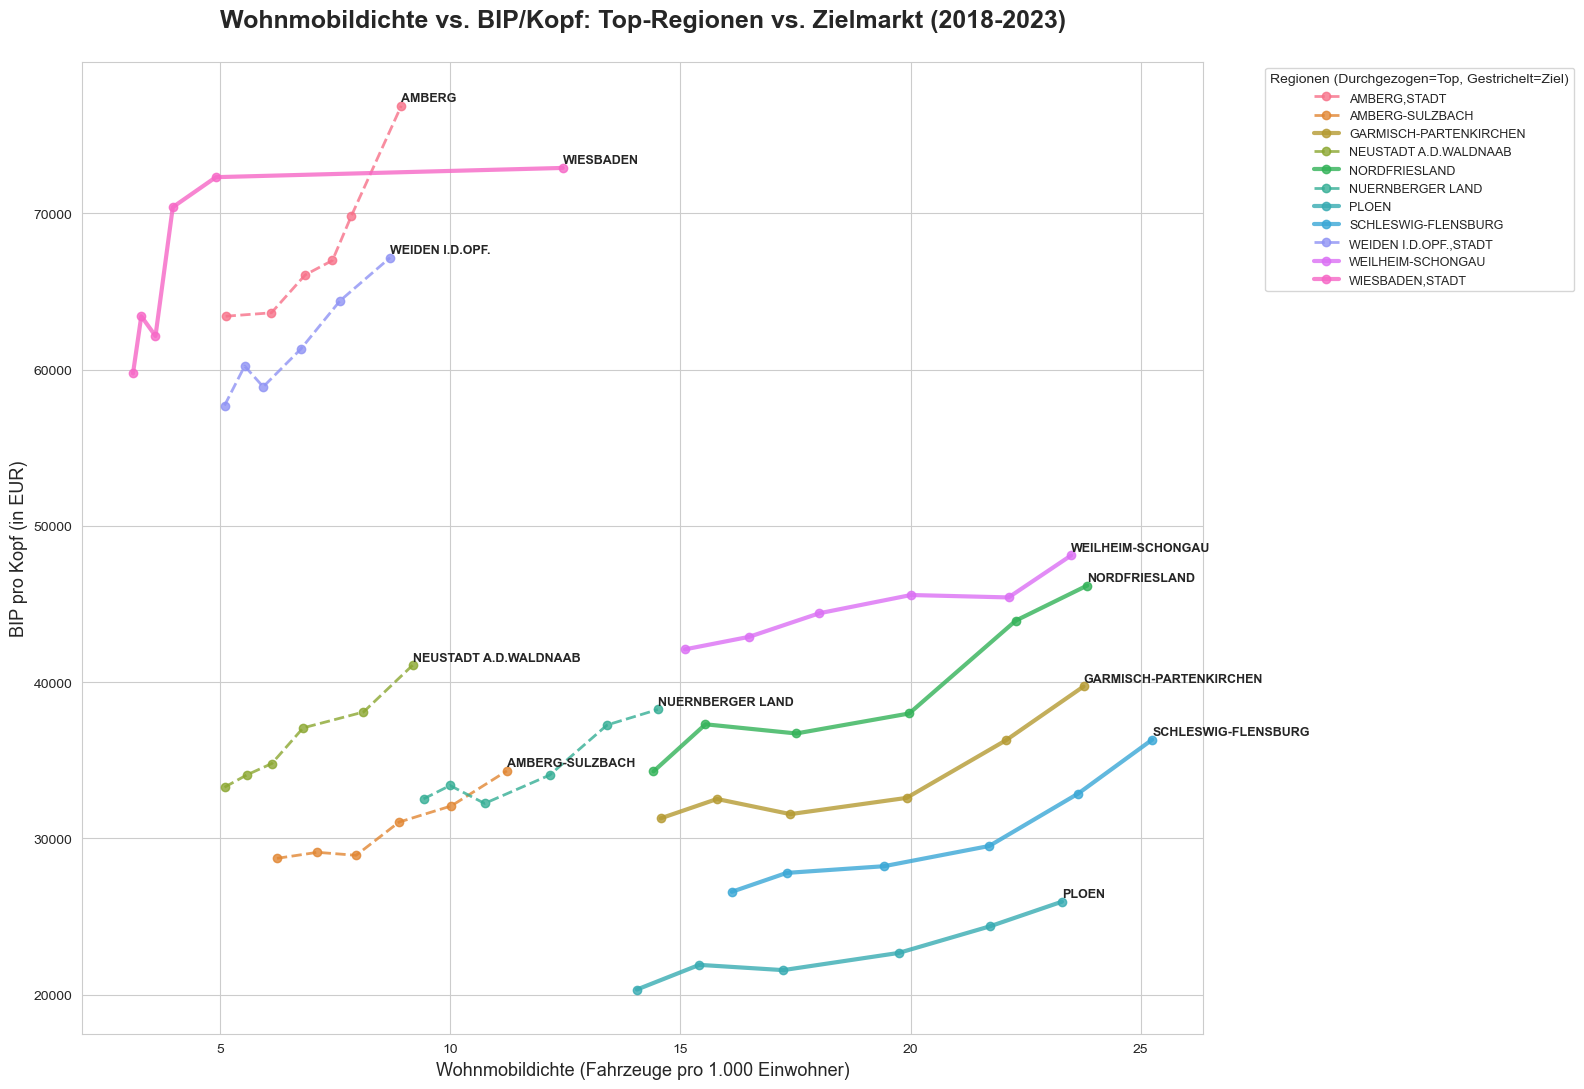

In [33]:
# 1. Daten filtern und sortieren
df_gesamt = merged_df[merged_df['PLZ'].isin(alle_plz)].copy()
df_gesamt = df_gesamt.sort_values(['zulassungsbezirk_name', 'jahr'])

# 2. Plot erstellen
plt.figure(figsize=(16, 11))
sns.set_style("whitegrid")

# Farbpalette für alle Regionen, optische Differenzierung: Top-Regionen in kalten Farben - Zielregionen in warmen Farben
palette = sns.color_palette("husl", len(alle_plz))

for i, (name, group) in enumerate(df_gesamt.groupby('zulassungsbezirk_name')):
    # Kennzeichnung, ob es eine Top-Region oder Zielregion ist
    is_top = group['PLZ'].iloc[0] in top_6_plz
    linestyle = '-' if is_top else '--'
    linewidth = 3 if is_top else 2
    
    # Pfad zeichnen
    plt.plot(group['Wohnmobildichte pro 1.000 Einwohner'], 
             group['BIP_pro_Kopf'], 
             marker='o', markersize=6, linewidth=linewidth, linestyle=linestyle,
             label=name, color=palette[i], alpha=0.8)
    
    # Nur den letzten Punkt (2023) beschriften, damit es nicht zu voll wird
    last_point = group.iloc[-1]
    plt.text(last_point['Wohnmobildichte pro 1.000 Einwohner'], 
             last_point['BIP_pro_Kopf'] + 300, 
             name.split(',')[0], fontsize=9, fontweight='bold')

# 3. Styling
plt.title('Wohnmobildichte vs. BIP/Kopf: Top-Regionen vs. Zielmarkt (2018-2023)', 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Wohnmobildichte (Fahrzeuge pro 1.000 Einwohner)', fontsize=13)
plt.ylabel('BIP pro Kopf (in EUR)', fontsize=13)

# 4. Legende
plt.legend(title='Regionen (Durchgezogen=Top, Gestrichelt=Ziel)', 
           bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# 5. Export als JPEG
plt.savefig('gesamtvergleich_pfade_2018_2023.jpg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

Die Zielmarktregionen weisen eine wirtschaftliche Stärke vergleichbar mit den Top-Regionen Deutschlands auf.

### 3.1 Validierung eines statistischen Zusammenhanges: Wirtschaftskraft vs. Wohnmobildichte

Es stellt sich jedoch die Frage, ob es einen statistischen Zusammenhang zwischen BIP/Kopf und der Wohnmobildichte gibt.  

Dazu wird eine Regressionsanalyse zwischen Wohnmobildichte und BIP/Kopf erstellt:

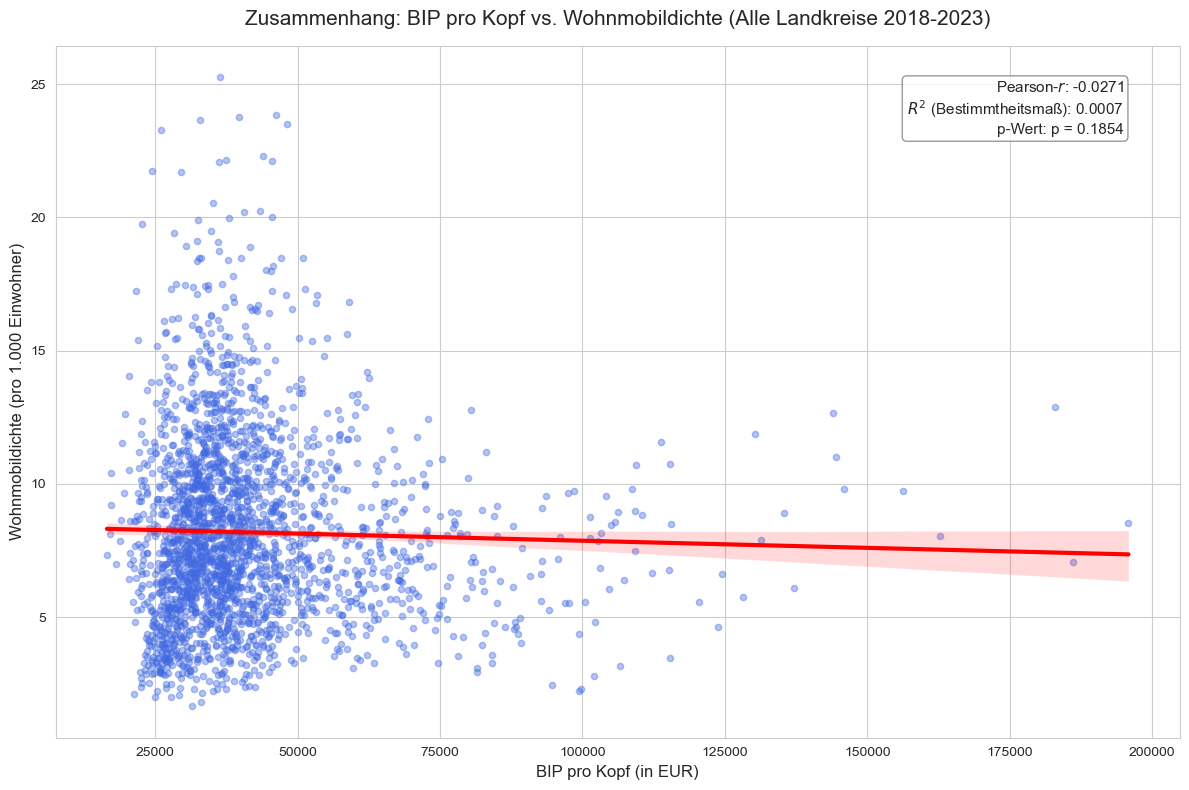

Pearson-r: -0.0271
R²: 0.0007
p-Wert: 0.18544793648997462


In [34]:
# 1. Plot-Stil festlegen
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 2. Regression-Plot erstellen
reg_plot = sns.regplot(
    data=merged_df, 
    x='BIP_pro_Kopf', 
    y='Wohnmobildichte pro 1.000 Einwohner',
    scatter_kws={'alpha':0.4, 'color': 'royalblue', 's': 20},
    line_kws={'color': 'red', 'linewidth': 3}
)

# 3. Statistische Kennziffern berechnen
r_val, p_val = stats.pearsonr(merged_df['BIP_pro_Kopf'], merged_df['Wohnmobildichte pro 1.000 Einwohner'])
r_squared = r_val ** 2

# 4. Text für die Box formatieren (wenn der p-Wert extrem klein ist, wird er wissenschaftlich dargestellt (z.B. < 0.001))
p_text = f"p < 0.001" if p_val < 0.001 else f"p = {p_val:.4f}"

textstr = (
    f"Pearson-$r$: {r_val:.4f}\n"
    f"$R^2$ (Bestimmtheitsmaß): {r_squared:.4f}\n"
    f"p-Wert: {p_text}"
)

# 5. Textbox im Diagramm platzieren (transform=plt.gca().transAxes sorgt dafür, dass (0.95, 0.95) oben rechts im Koordinatensystem liegt)
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# Achsen und Titel
plt.title('Zusammenhang: BIP pro Kopf vs. Wohnmobildichte (Alle Landkreise 2018-2023)', fontsize=15, pad=15)
plt.xlabel('BIP pro Kopf (in EUR)', fontsize=12)
plt.ylabel('Wohnmobildichte (pro 1.000 Einwohner)', fontsize=12)

# 6. Grafik als JPEG exportieren
plt.savefig('korrelation_bip_womodichte.jpg', format='jpg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# Konsolen-Ausgabe zur Kontrolle
print(f"Pearson-r: {r_val:.4f}")
print(f"R²: {r_squared:.4f}")
print(f"p-Wert: {p_val}")

**Analyse der Ergebnisse:**  
Aufgrund des hohen p-Wertes gibt es in dem untersuchten Datensatz keinen statistisch signifikanten Zusammenhang zwischen dem BIP/Kopf und der Wohnmobildichte.

# 6. Beantwortung der Projekt-Fragestellungen

Wachstumspotenzial: Die Zielregion weist ein erhebliches, ungenutztes Wachstumspotenzial für spezialisierte Fahrzeug- und Flottendienstleistungen auf.  

Benchmark-Resilienz: Die historische Entwicklung spiegelt die Trajektorien der leistungsstärksten regionalen Wohnmobilmärkte Deutschlands wider.  

Entkoppelte Nachfrage: Die statistische Analyse zeigt, dass die regionale Wirtschaftskraft allein nicht mit der lokalen Wohnmobildichte korreliert.  

Multivariate Treiber: Die Nachfrage wird eher durch sekundäre soziodemografische Faktoren und regionale Infrastrukturmerkmale als durch den reinen Wohlstand bestimmt. 